# PC Weights vs Louvain Cluster Assignments — ANOVA

This notebook tests how principal component weights load onto Louvain cluster assignments.

1. **Setup** — load feature vectors, compute cosine similarity matrices, run PCA
2. **Louvain clustering** — assign each region to a community
3. **Mean PC scores per cluster** — how does each PC load onto each cluster?
4. **One-way ANOVA** — which PCs significantly separate clusters?
5. **Effect size (η²)** — how much variance in each PC is explained by cluster membership?
6. **Post-hoc (Tukey HSD)** — pairwise comparisons for the most discriminating PC
7. **Visualisations** — heatmap, η² bar chart, boxplot

### Setup — PCA on cosine similarity matrices

In [1]:
import numpy as np
import pandas as pd
import bct
from helpers import get_feature_vectors_shared_hpc, get_correlation_matrix
from sklearn.decomposition import PCA

# Load feature vectors
df_avg_to_shared, df_avg_from_shared = get_feature_vectors_shared_hpc()

# Cosine similarity matrices
df_cosine_to_shared = get_correlation_matrix(df_avg_to_shared, 'cosine')
df_cosine_from_shared = get_correlation_matrix(df_avg_from_shared, 'cosine')

matrix_afferent = df_cosine_to_shared.values   # incoming connections
matrix_efferent = df_cosine_from_shared.values  # outgoing connections

# PCA
n_components = 7

pca_afferent = PCA(n_components=n_components, svd_solver='full')
pca_afferent.fit(matrix_afferent)
weights_a = pca_afferent.components_  # shape (n_components, n_regions)
vars_a = pca_afferent.explained_variance_ratio_

pca_efferent = PCA(n_components=n_components, svd_solver='full')
pca_efferent.fit(matrix_efferent)
weights_e = pca_efferent.components_
vars_e = pca_efferent.explained_variance_ratio_

print(f"Afferent explained variance: {np.round(vars_a, 3)}")
print(f"Efferent explained variance: {np.round(vars_e, 3)}")

Afferent explained variance: [0.434 0.261 0.148 0.099 0.041 0.011 0.006]
Efferent explained variance: [0.618 0.267 0.092 0.018 0.004 0.    0.   ]


### Community assignments from Louvain

In [2]:
# Louvain community detection
gamma_resolution = 1.0

community_assignments_e, modularity_score_e = bct.community_louvain(
    matrix_efferent, gamma=gamma_resolution, seed=42)

community_assignments_a, modularity_score_a = bct.community_louvain(
    matrix_afferent, gamma=gamma_resolution, seed=42)

print(f"Efferent: {len(np.unique(community_assignments_e))} communities, Q={modularity_score_e:.3f}")
print(f"Afferent: {len(np.unique(community_assignments_a))} communities, Q={modularity_score_a:.3f}")

Efferent: 3 communities, Q=0.105
Afferent: 4 communities, Q=0.103


In [9]:
weights_e[0]

array([ 0.1164289 , -0.06826246, -0.07194354,  0.16910024,  0.1678066 ,
        0.09829313,  0.13703614,  0.13703614,  0.1678066 ,  0.13173778,
       -0.05845104,  0.02329289,  0.12008047, -0.02885338, -0.10546294,
        0.1678066 ,  0.02863937,  0.07772305,  0.15404117,  0.1678066 ,
        0.13703614,  0.11470881,  0.14727186,  0.14984034,  0.10840468,
        0.13791759, -0.14140428,  0.13350466,  0.02705295,  0.01380405,
        0.00267989,  0.00674834,  0.01271646, -0.13586936,  0.03200089,
       -0.07796371, -0.08885498,  0.08645455,  0.14432348,  0.09829313,
        0.16171466,  0.09829313,  0.16910024,  0.13703614,  0.13703614,
        0.02599176,  0.16910024,  0.1678066 ,  0.1678066 ,  0.15404117,
        0.1678066 ,  0.10094081,  0.16545762,  0.02599176,  0.16910024,
        0.13703614,  0.1678066 ,  0.08989655,  0.15404117,  0.1106459 ,
        0.07274429, -0.0046729 ,  0.02599176,  0.06611394,  0.04116151,
        0.16964531,  0.02626547, -0.14140428,  0.02599176, -0.08

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

n_pcs = 7
pc_labels = [f"PC{i+1}" for i in range(n_pcs)]


def run_pc_cluster_anova(weights, community_assignments, label):
    """
    Compute mean PC scores per Louvain cluster and run one-way ANOVA
    for each PC to identify which PCs significantly separate clusters.

    Parameters
    ----------
    weights : ndarray, shape (n_pcs, n_regions)
        PCA component weights (pca.components_).
    community_assignments : ndarray, shape (n_regions,)
        Integer cluster label per region.
    label : str
        Human-readable label for printing (e.g. 'Efferent').

    Returns
    -------
    pc_df : DataFrame  — tidy frame with PC scores + cluster column
    mean_scores : DataFrame — mean PC score per cluster
    anova_df : DataFrame — F-statistic, p-value, significance flag per PC
    eta_df : Series — eta-squared (effect size) per PC, sorted descending
    """
    clusters = np.unique(community_assignments)

    # Tidy DataFrame: rows = regions, cols = PC scores + cluster
    pc_df = pd.DataFrame(weights.T, columns=pc_labels)
    pc_df["cluster"] = community_assignments.astype(str)

    # ── Mean PC score per cluster ────────────────────────────────────────────
    mean_scores = pc_df.groupby("cluster")[pc_labels].mean()

    print(f"\n{'='*62}")
    print(f"  {label.upper()}")
    print(f"{'='*62}")
    print("\n  Mean PC score per cluster:")
    print(mean_scores.round(4).to_string())

    # ── One-way ANOVA per PC ─────────────────────────────────────────────────
    anova_results = {}
    for pc in pc_labels:
        groups = [pc_df.loc[pc_df["cluster"] == str(c), pc].values for c in clusters]
        f_stat, p_val = stats.f_oneway(*groups)
        anova_results[pc] = {"F-statistic": round(f_stat, 4), "p-value": round(p_val, 4)}

    anova_df = pd.DataFrame(anova_results).T
    anova_df["significant (p<0.05)"] = anova_df["p-value"] < 0.05

    print("\n  One-way ANOVA (F and p per PC):")
    print(anova_df.to_string())

    # ── Eta-squared (effect size) ────────────────────────────────────────────
    eta_sq = {}
    for pc in pc_labels:
        grand_mean = pc_df[pc].mean()
        ss_between = sum(
            len(pc_df[pc_df["cluster"] == str(c)]) *
            (pc_df[pc_df["cluster"] == str(c)][pc].mean() - grand_mean) ** 2
            for c in clusters
        )
        ss_total = ((pc_df[pc] - grand_mean) ** 2).sum()
        eta_sq[pc] = ss_between / ss_total

    eta_df = pd.Series(eta_sq, name="eta_squared").sort_values(ascending=False)

    print("\n  Eta-squared per PC (sorted, higher = better cluster separation):")
    print(eta_df.round(4).to_string())

    # ── Tukey HSD post-hoc for the most discriminating PC ───────────────────
    best_pc = eta_df.index[0]
    print(f"\n  Tukey HSD post-hoc for {best_pc} (highest η²={eta_df[best_pc]:.4f}):")
    tukey = pairwise_tukeyhsd(endog=pc_df[best_pc], groups=pc_df["cluster"], alpha=0.05)
    print(tukey)

    return pc_df, mean_scores, anova_df, eta_df


# ── Run for both connection directions ──────────────────────────────────────
pc_df_e, mean_scores_e, anova_df_e, eta_df_e = run_pc_cluster_anova(
    weights_e, community_assignments_e, "Efferent (outgoing connections)")

pc_df_a, mean_scores_a, anova_df_a, eta_df_a = run_pc_cluster_anova(
    weights_a, community_assignments_a, "Afferent (incoming connections)")


  EFFERENT (OUTGOING CONNECTIONS)

  Mean PC score per cluster:
            PC1     PC2     PC3     PC4     PC5     PC6     PC7
cluster                                                        
1        0.1534 -0.0510  0.0331  0.0160  0.0256  0.0172  0.0057
2       -0.0408 -0.0123  0.1978  0.0432 -0.0022 -0.0143  0.0039
3        0.0816  0.1450  0.0408 -0.0040  0.0257 -0.0057 -0.0083

  One-way ANOVA (F and p per PC):
     F-statistic  p-value  significant (p<0.05)
PC1      91.1287   0.0000                  True
PC2      43.3342   0.0000                  True
PC3     122.0236   0.0000                  True
PC4       0.9071   0.4085                 False
PC5       0.4115   0.6643                 False
PC6       0.4562   0.6356                 False
PC7       0.0981   0.9067                 False

  Eta-squared per PC (sorted, higher = better cluster separation):
PC3    0.7796
PC1    0.7254
PC2    0.5568
PC4    0.0256
PC6    0.0131
PC5    0.0118
PC7    0.0028

  Tukey HSD post-hoc for PC3 

In [4]:
pc_df_e

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,cluster
0,0.116429,0.088989,0.006249,0.118883,0.171898,-0.079993,0.074846,3
1,-0.068262,0.168606,0.112348,0.116127,0.273780,-0.086191,0.104707,2
2,-0.071944,0.160739,0.129075,0.191885,0.107401,-0.195985,0.100442,2
3,0.169100,-0.077143,0.022514,0.005852,0.044938,0.003762,-0.023295,1
4,0.167807,-0.145560,0.014995,0.026072,0.056666,0.011412,0.061473,1
...,...,...,...,...,...,...,...,...
67,-0.141404,-0.078410,0.259278,-0.105182,0.141361,0.070047,-0.008534,2
68,0.025992,0.264172,0.032848,-0.080159,-0.041380,-0.030139,0.051874,3
69,-0.087639,-0.045969,0.255726,-0.111915,0.136879,0.061627,0.047010,2
70,-0.141404,-0.078410,0.259278,-0.105182,0.141361,0.070047,-0.008534,2


/var/folders/4k/31jdbs595pn4tslnsm4nxmzm0000gq/T/ipykernel_15118/449547451.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pc_df, x="cluster", y=best_pc, palette=palette, ax=axes[row, 2])
/var/folders/4k/31jdbs595pn4tslnsm4nxmzm0000gq/T/ipykernel_15118/449547451.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pc_df, x="cluster", y=best_pc, palette=palette, ax=axes[row, 2])


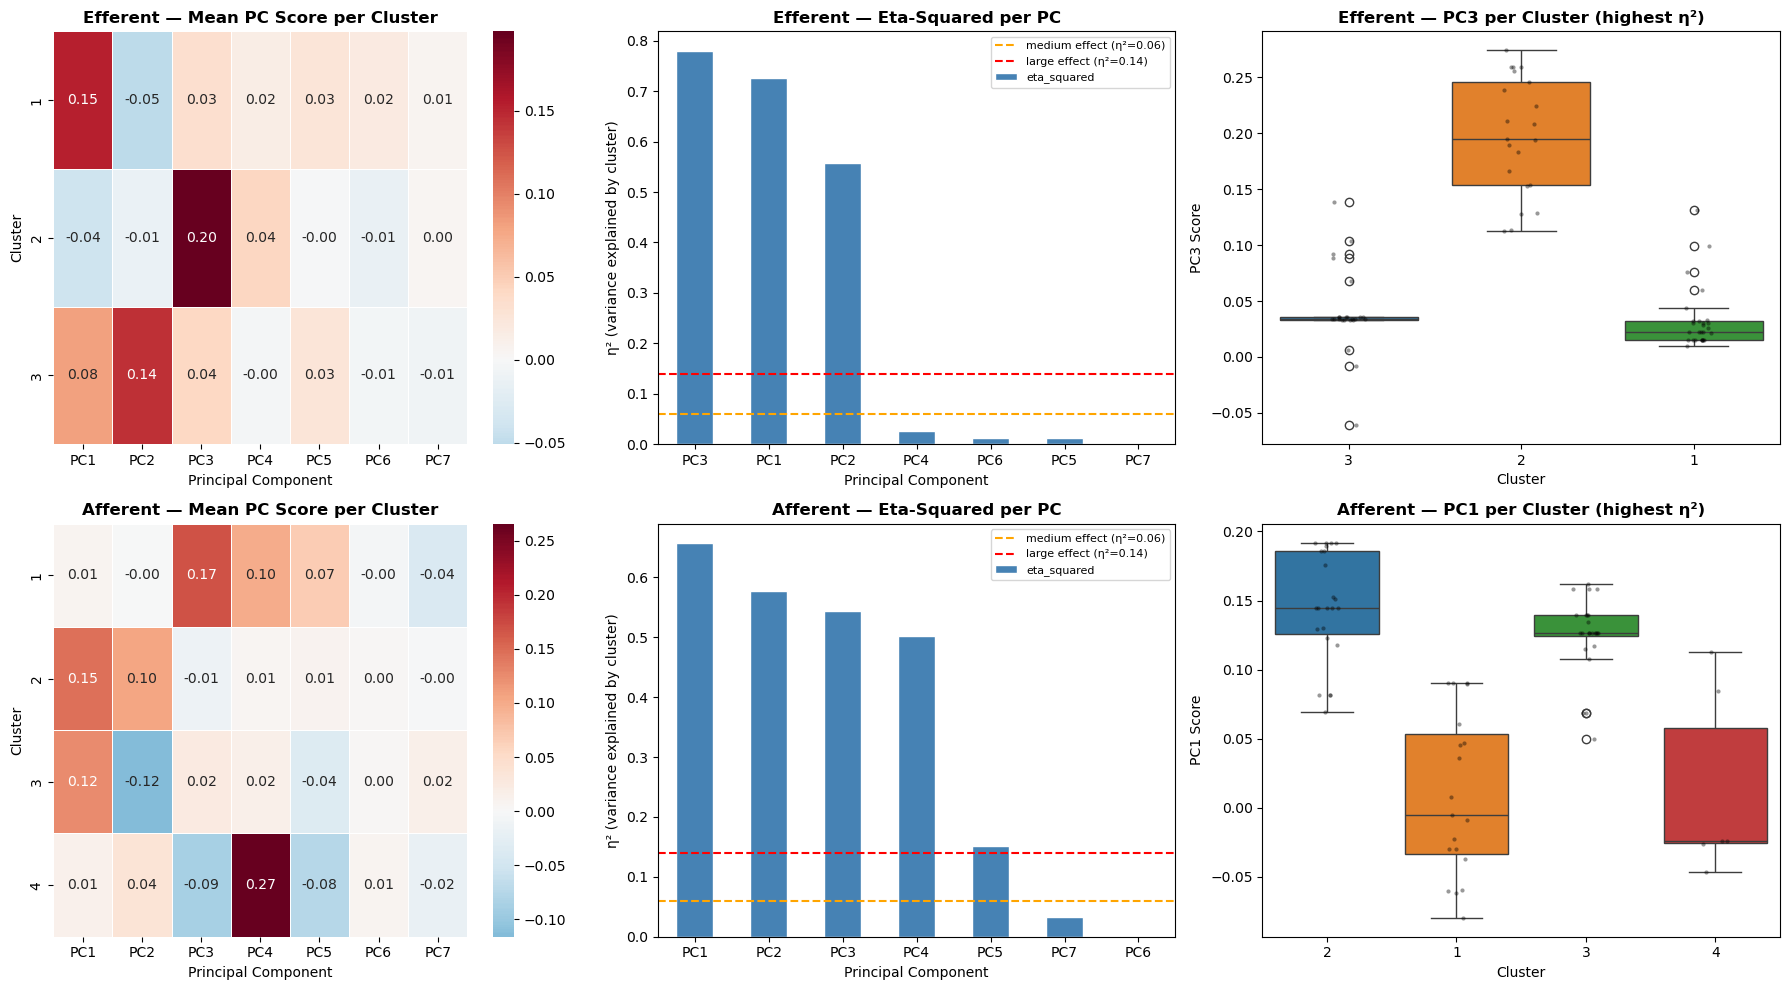

In [7]:
# ── Visualisations: 2 rows (efferent / afferent) × 3 columns ───────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

configs = [
    (mean_scores_e, eta_df_e, pc_df_e, community_assignments_e, "Efferent"),
    (mean_scores_a, eta_df_a, pc_df_a, community_assignments_a, "Afferent"),
]

for row, (mean_scores, eta_df, pc_df, assignments, lbl) in enumerate(configs):
    clusters = np.unique(assignments)
    palette = sns.color_palette("tab10", len(clusters))
    best_pc = eta_df.index[0]

    # Col 0: Heatmap — mean PC score per cluster
    sns.heatmap(
        mean_scores, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
        linewidths=0.5, ax=axes[row, 0]
    )
    axes[row, 0].set_title(f"{lbl} — Mean PC Score per Cluster", fontweight="bold")
    axes[row, 0].set_xlabel("Principal Component")
    axes[row, 0].set_ylabel("Cluster")

    # Col 1: Bar chart — eta-squared (cluster separability per PC)
    eta_df.plot(kind="bar", ax=axes[row, 1], color="steelblue", edgecolor="white")
    axes[row, 1].axhline(0.06, color="orange", linestyle="--", label="medium effect (η²=0.06)")
    axes[row, 1].axhline(0.14, color="red",    linestyle="--", label="large effect (η²=0.14)")
    axes[row, 1].set_title(f"{lbl} — Eta-Squared per PC", fontweight="bold")
    axes[row, 1].set_xlabel("Principal Component")
    axes[row, 1].set_ylabel("η² (variance explained by cluster)")
    axes[row, 1].set_xticklabels(axes[row, 1].get_xticklabels(), rotation=0)
    axes[row, 1].legend(fontsize=8)

    # Col 2: Boxplot — distribution of the most discriminating PC
    sns.boxplot(data=pc_df, x="cluster", y=best_pc, palette=palette, ax=axes[row, 2])
    sns.stripplot(data=pc_df, x="cluster", y=best_pc,
                  color="black", alpha=0.4, size=3, ax=axes[row, 2])
    axes[row, 2].set_title(f"{lbl} — {best_pc} per Cluster (highest η²)", fontweight="bold")
    axes[row, 2].set_xlabel("Cluster")
    axes[row, 2].set_ylabel(f"{best_pc} Score")

plt.tight_layout()
plt.savefig("pc_cluster_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## Some notes

### Regarding negative loadings
Why loadings can be negative
                              
  PCA eigenvectors define directional axes through the feature space — they are not scores or magnitudes. They encode contrasts:
                                                                                                                                                       
  - A positive loading on PC1 means that region co-varies with the positive direction of PC1.                                                          
  - A negative loading means it varies in the opposite direction.                                                                                      
                                                                                                                                                       
  Concretely, since your input is a cosine similarity matrix (rows = regions, each row = that region's similarity profile to all 72 others), PC1 finds 
  the direction of maximum variance across those profiles. Regions with high positive loadings have connectivity profiles that pull in the same        
  direction along that axis; regions with high negative loadings have profiles that pull the opposite way. It's a bipolar contrast axis.               
                                                            
  The sign of an eigenvector is also mathematically arbitrary — if v is an eigenvector, so is −v, both are valid. What's meaningful is not the absolute
   sign, but the relative sign pattern: which regions are positive vs. negative relative to each other on a given PC.
                                                                                                                                                       
  ---                                                       
  Practical implication for your analysis
                                                                                                                                                       
  A cluster with a strongly negative mean loading on PC2, say, means its member regions collectively sit on the "negative pole" of whatever
  connectivity contrast PC2 captures. Another cluster with a strongly positive mean on the same PC sits on the "positive pole." That's exactly what    
  ANOVA is testing — whether the distribution of loadings differs significantly across clusters, regardless of the sign.
                                                                                                                                                       
  One thing worth noting: the values in weights.T are loadings, not scores in the traditional PCA sense. Scores would be matrix @ weights.T (projecting
   the original data onto the PC axes). Loadings tell you the direction each PC points in feature space. Since your similarity matrix is square
  (regions × regions), both representations end up being the same dimensionality and are often used interchangeably, but they answer subtly different  
  questions. 


### What is the eta-squared measuring? 
What PCA variance explained measures                                                                                                                 
                                                                                                                                                       
PC1 explains the most variance in the input data — i.e., the most variance in the 72×72 cosine similarity matrix. It captures the single largest axis
of variation in connectivity profiles across all regions, regardless of cluster structure.                                                          
                                                        
What eta-squared measures                                                                                                                            
                                                        
Eta-squared measures how much variance in the PC loadings is explained by cluster membership. It's asking: of the variation in this PC's loadings    
across regions, how much of it aligns with the Louvain partition?
                                                                                                                                                   
---                                                       
Why these can disagree
                    
PC1 capturing the most total variance doesn't mean that variance is structured by cluster. It could be that PC1 captures a smooth gradient that runs
continuously across all regions, with no step-change at cluster boundaries — clusters would then have similar mean loadings on PC1, giving low η².   

PC3, by contrast, might capture a smaller amount of total variance, but that variance could be tightly concentrated along cluster boundaries — one   
cluster loads positively, another loads negatively, with little within-cluster spread. That pattern produces high η² even though PC3 "matters less"
globally.                                                                                                                                            
                                                        
A concrete analogy: if you recorded brain activity during a task, the first PC might capture global arousal (everyone goes up and down together). A  
later PC might capture the contrast between two specific brain regions. The later PC explains less total variance but perfectly separates a two-group
condition. η² would be highest for that PC.                                                                                                         
                                                        
---
In your specific case
                                                                                                                                                   
The fact that PC3 has the highest η² is actually an interesting finding — it suggests the Louvain clusters are most clearly differentiated by the
third axis of connectivity variation, not the dominant one. PC1 and PC2 might reflect global or continuous connectivity gradients shared across      
clusters, while PC3 captures a specific contrast that aligns with the community structure. That's worth interpreting in terms of what the biology of
those connectivity patterns actually is.

---

## Expanded notes: steps and interpretation

---

### Step 1 — Feature vectors and cosine similarity matrices

`get_feature_vectors_shared_hpc()` returns two DataFrames of connectivity profiles: one for afferent (incoming) connections and one for efferent (outgoing) connections. Each row is a brain region and each column is its average connectivity weight to/from another region — i.e., the raw feature representation of each region's connectivity fingerprint.

We then compute a **cosine similarity matrix** from each of these. The cosine similarity between two regions' connectivity profiles measures how similar their *pattern* of connections is, independent of overall connection strength. The result is a symmetric 72×72 matrix where entry (i, j) reflects how similarly regions i and j connect to the rest of the brain (afferently or efferently).

This matrix is what PCA is run on. Each *row* of the similarity matrix is treated as one observation: each region is described by its vector of pairwise cosine similarities to all other 72 regions.

---

### Step 2 — PCA

PCA is run on each 72×72 similarity matrix separately. With `n_components=7`, we retain the 7 directions of greatest variance in that similarity space.

`pca.components_` has shape `(n_pcs, n_regions)` — each row is an eigenvector (a PC axis), and each entry in that row is the **loading** of a given region onto that PC. `pca.explained_variance_ratio_` tells you what fraction of the total variance in the similarity matrix is captured by each PC. By construction, PC1 ≥ PC2 ≥ PC3 ≥ ... in terms of variance explained.

These loadings are *not* scores in the standard sense. Scores (projections of the data onto the PC axes) would be computed as `matrix @ components.T`. Because the input matrix is square (72 regions × 72 regions), both representations share the same dimensionality, but they answer subtly different questions:

- **Loadings** (`pca.components_[i, j]`): how much region j contributes to the direction of PC axis i. This is a property of the PC axis itself.
- **Scores** (`matrix @ components.T`): how far each observation (region row) projects along each PC axis. This is a property of the data point.

In this notebook, we use loadings directly. The mean loading per cluster tells you which direction (positive vs. negative pole of each PC axis) the cluster's regions collectively point toward.

---

### Step 3 — Louvain community detection

Louvain clustering is run on the same cosine similarity matrices used for PCA. It partitions the 72 regions into communities by maximising modularity — groups of regions that are more similar to each other than expected by chance.

`gamma` controls resolution: higher values tend to produce more, smaller communities. At `gamma=1.0` (default), the efferent matrix yields 3 communities and the afferent matrix yields 4.

The modularity score **Q** ranges from −0.5 to 1. Values above ~0.3 indicate strong community structure; values in the 0.1–0.3 range suggest moderate structure. Both matrices produce Q ≈ 0.10, indicating modest but detectable community organisation.

---

### Step 4 — Mean PC loading per cluster

For each PC, we compute the mean loading across all regions belonging to each Louvain cluster. This answers: **does this PC axis systematically separate the clusters from one another?**

- A cluster with a high **positive** mean loading sits on the positive pole of that PC's contrast axis.
- A cluster with a high **negative** mean loading sits on the negative pole.
- A cluster with a mean **near zero** is ambiguous on that axis — its regions scatter on both sides, so the PC does not cleanly characterise it.

Large differences in mean loading between clusters (one cluster strongly positive, another strongly negative) indicate that the PC is capturing a connectivity contrast that aligns with community structure. Small differences indicate the PC captures variation that is distributed across clusters, not between them.

The sign of a loading is **mathematically arbitrary** — if **v** is a valid eigenvector, so is −**v**. What is meaningful is the *relative* sign pattern: which clusters are positive vs. negative *with respect to each other* on a given PC axis.

---

### Step 5 — One-way ANOVA

For each PC, a one-way ANOVA tests whether the mean loading differs significantly across clusters.

**Null hypothesis:** the mean loading on this PC is the same across all clusters — cluster membership tells you nothing about where a region sits on this PC axis.

**F-statistic:** ratio of between-cluster variance to within-cluster variance. A large F means clusters differ more, relative to how variable regions are within each cluster.

**p-value:** probability of observing an F this extreme under the null hypothesis. We use p < 0.05 as the significance threshold.

A significant ANOVA on PC*k* means that the Louvain partition is non-randomly associated with that PC axis. It does *not* identify which specific pairs of clusters differ — that requires the Tukey HSD post-hoc test.

**Caveats:** ANOVA assumes (1) independence of observations, (2) approximate normality within groups, and (3) homogeneity of variance across groups (Levene's test can check this). With n=72 regions split into 3–4 clusters, group sizes are moderately small and these assumptions should be kept in mind when interpreting results, particularly for borderline p-values.

---

### Step 6 — Eta-squared (effect size)

The F-statistic and p-value indicate whether an effect exists; eta-squared (η²) quantifies how large it is. η² is the proportion of total variance in PC loadings explained by cluster membership:

$$\eta^2 = \frac{SS_{\text{between}}}{SS_{\text{total}}}$$

where $SS_{\text{between}}$ is the weighted sum of squared deviations of cluster means from the grand mean, and $SS_{\text{total}}$ is the total sum of squared deviations of all individual loadings from the grand mean.

- **η² = 0**: cluster membership explains none of the variance — clusters are indistinguishable on this PC.
- **η² = 1**: all variance is explained by cluster — every region within a cluster has the same loading, and clusters are perfectly separated.

Conventional effect size thresholds (Cohen, 1988): small ≥ 0.01, medium ≥ 0.06, large ≥ 0.14.

**η² and PCA variance explained are orthogonal quantities.** PC1 always explains the most variance *in the similarity matrix*, but this variance may be distributed continuously across all regions with no alignment to cluster boundaries, giving PC1 a low η². A later PC that captures less total variance may happen to encode exactly the contrast that separates clusters, giving it the highest η². **The PC with the highest η² is the one whose axis of variation most closely aligns with the Louvain partition** — this is the biologically most interpretable PC with respect to the community structure.

---

### Step 7 — Tukey HSD post-hoc test

Once ANOVA identifies that a PC significantly separates clusters, Tukey's Honestly Significant Difference (HSD) test performs all pairwise comparisons to identify *which* pairs of clusters differ.

For each pair (cluster A vs. cluster B), Tukey HSD reports:
- **meandiff**: difference in mean loading between the two clusters (positive = A higher than B)
- **p-adj**: p-value adjusted for multiple comparisons via the studentised range distribution, controlling the family-wise error rate
- **lower / upper**: 95% confidence interval on the mean difference
- **reject**: whether the null (no difference) is rejected at α = 0.05

This is run on the PC with the highest η², as it is the most likely to reveal interpretable pairwise structure. It can be extended to any PC flagged as significant in the ANOVA table.

---

### Step 8 — Visualisations

**Heatmap (left):** rows = clusters, columns = PCs, colour = mean loading. Blue = negative pole, red = positive pole, white ≈ zero. A clear block structure — one cluster strongly red on a PC, another strongly blue — indicates that PC strongly distinguishes those clusters. Clusters that are uniformly pale across all PCs are not well-characterised by any of the retained PC axes.

**Eta-squared bar chart (middle):** PCs sorted by η², with reference lines at medium (0.06) and large (0.14) effect sizes. This is the primary summary of which PC axes are structurally meaningful for the Louvain partition, independent of how much total variance they explain. PCs above the large-effect threshold are the strongest candidates for biological interpretation.

**Boxplot (right):** distribution of individual region loadings on the highest-η² PC, split by cluster. The box shows median and interquartile range; the strip plot overlaid shows individual regions. Well-separated, non-overlapping distributions visually confirm the ANOVA/Tukey findings. Overlapping distributions or high within-cluster spread suggest that the PC captures a gradient rather than a clean step-change at cluster boundaries, or that the cluster assignment is partially misspecified for some regions.